In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RS Panti Waluyo Yakkum Surakarta']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
4780,RS Panti Waluyo Yakkum Surakarta,5,karyawan dan suster sangat ramah sekali walaup...,1,0,['pelayanan'],positive,0.997153,0.004966
4781,RS Panti Waluyo Yakkum Surakarta,5,fasilitas oke kelas 2 hanya di isi 1 pasien se...,0,1,['fasilitas'],positive,0.006811,0.993889
4782,RS Panti Waluyo Yakkum Surakarta,5,pelayanan sungguh memuaskan,1,0,['pelayanan'],positive,0.997203,0.004603
4783,RS Panti Waluyo Yakkum Surakarta,5,pelayanan yang sangat memuaskantempat nyamanga...,1,1,"['pelayanan', 'fasilitas']",positive,0.997193,0.987057
4784,RS Panti Waluyo Yakkum Surakarta,5,pertama kali saya rawat inap ank dirs panti wa...,1,0,['pelayanan'],positive,0.999024,0.487177
...,...,...,...,...,...,...,...,...,...
5829,RS Panti Waluyo Yakkum Surakarta,5,pelayanan bagus dan ramah lengkap dekat dengan...,1,0,['pelayanan'],positive,0.999324,0.363633
5830,RS Panti Waluyo Yakkum Surakarta,5,rumah sakit yang bersih dan bersahabat baik ke...,1,1,"['pelayanan', 'fasilitas']",positive,0.992343,0.994054
5831,RS Panti Waluyo Yakkum Surakarta,5,pelayanan ramah terima macammacam asuransi,1,0,['pelayanan'],positive,0.998914,0.130532
5832,RS Panti Waluyo Yakkum Surakarta,5,pelayanan profesional dengan sentuhan kekeluar...,1,0,['pelayanan'],positive,0.996364,0.004211


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

5
5


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,13,-1_biasa_luar_menarik_acara,"[biasa, luar, menarik, acara, kegiatannya, men...","[operasi luar biasa, luar biasa, luar biasa]"
1,0,930,0_pelayanan_ramah_sangat_rs,"[pelayanan, ramah, sangat, rs, baik, panti, wa...","[pelayanan baik cepat ramah, pelayanan baik..."
2,1,27,1_bagus_baik_keren_jadilah,"[bagus, baik, keren, jadilah, bagusramahterjan...","[bagus, bagus, bagus]"
3,2,12,2_josssss_bagys_baguuuus_lojiwetan,"[josssss, bagys, baguuuus, lojiwetan, mantaap,...","[Uda Bagys, nasgor mantabmasseh, pekerjaan te..."
4,3,13,3_terbaik_stabil_menyesap_klemer,"[terbaik, stabil, menyesap, klemer, klemar, ro...","[terbaik, terbaik, rs terbaik]"


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5,-1_pekerjaan_indak_sana_tenen,"[pekerjaan, indak, sana, tenen, inpus, anak2, ...","[banyak program menarik, pekerjaan tenen sana..."
1,0,258,0_pelayanan_ramah_bersih_rumah,"[pelayanan, ramah, bersih, rumah, rs, sakit, b...",[pelayanan sangat baik dokter serta suster r...
2,1,43,1_sangat_bermanfaat_bagi_menjadi,"[sangat, bermanfaat, bagi, menjadi, biasa, ber...","[sangat menjadi berkat, sangat bermanfaat bagi..."
3,2,18,2_terbaik_lojiwetan_klemar_klemer,"[terbaik, lojiwetan, klemar, klemer, bagys, ga...","[terbaik, terbaik, pendukung acara olahraga]"
4,3,29,3_bagus_keren_baik_baguss,"[bagus, keren, baik, baguss, bagusramahterjang...","[Bagus, Bagus, bagus]"


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0             78       51       801
1              0        0        27
2              1        0        11
3              4        3         6

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.083871  0.054839  0.861290
1       0.000000  0.000000  1.000000
2       0.083333  0.000000  0.916667
3       0.307692  0.230769  0.461538

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0             18       19       221
1              4        2        37
2              3        4        11
3              0        0        29

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0       0.069767  0.073643  0.856589
1       0.093023  0.046512  0.860465
2  

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

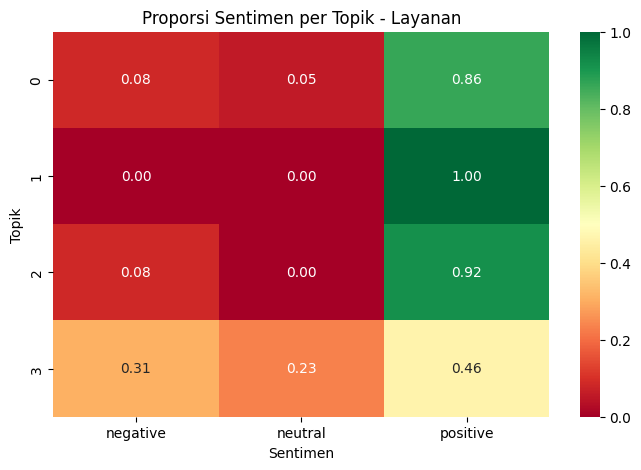

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

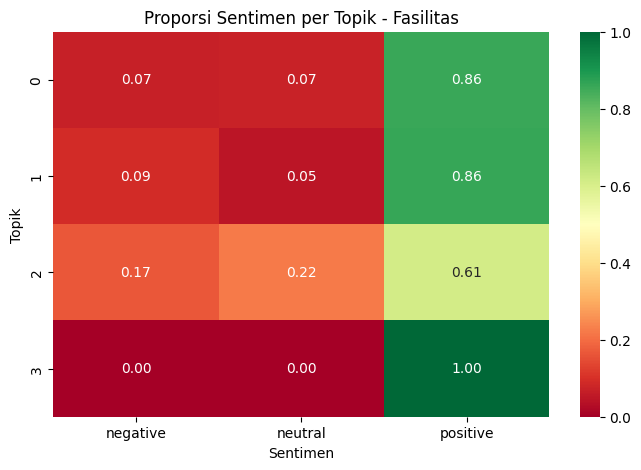

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic -1:
Representasi: [('biasa', np.float64(0.9427232727875345)), ('luar', np.float64(0.48768957956367603)), ('menarik', np.float64(0.410595060779805)), ('acara', np.float64(0.357475180047434)), ('kegiatannya', np.float64(0.2836684835919211)), ('menguntungkan', np.float64(0.2836684835919211)), ('tindakannya', np.float64(0.2836684835919211)), ('olahraga', np.float64(0.2836684835919211)), ('pendukung', np.float64(0.2836684835919211)), ('keren', np.float64(0.20949141395474727))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.06684553489787345)), ('ramah', np.float64(0.05635123782751492)), ('sangat', np.float64(0.05288067353160326)), ('rs', np.float64(0.04692885508725629)), ('baik', np.float64(0.043526660145465905)), ('panti', np.float64(0.041067784822252165)), ('waluyo', np.float64(0.03895220340786777)), ('dokter', np.float64(0.03759955688224284)), ('pasien', np.float64(0.0351310738672633)), ('ba

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

8
3


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,254,-1_pelayanan_ramah_baik_rs,"[pelayanan, ramah, baik, rs, sangat, bpjs, cep...","[pelayanan baik ramah, pelayanan baik cepat..."
1,0,170,0_pelayanan_ramah_baik_bagus,"[pelayanan, ramah, baik, bagus, sangat, pelaya...","[pelayanan ramah, pelayanan cepat ramah sanga..."
2,1,111,1_ramah_pelayanan_bersih_bagus,"[ramah, pelayanan, bersih, bagus, nyaman, cepa...",[pelayanan bagus tempat bersih dokternya baik...
3,2,107,2_bermanfaat_sangat_bagi_ilmu,"[bermanfaat, sangat, bagi, ilmu, gizi, acara, ...","[terimakasih ilmu sangat bermanfaat, seminar..."
4,3,107,3_rs_panti_waluyo_dokter,"[rs, panti, waluyo, dokter, sangat, pasien, ba...",[terima kasih rs panti waluyo selalu memberika...
5,4,52,4_rumah_sakit_pasien_baik,"[rumah, sakit, pasien, baik, pelayanan, dalam,...","[rumah sakit bersih cepat dalam pelayanan, r..."
6,5,45,5_bagus_keren_menarik_ok,"[bagus, keren, menarik, ok, baik, acara, yay, ...","[Bagus, bagus, bagus]"
7,6,43,6_waluyo_panti_rs_pelayanan,"[waluyo, panti, rs, pelayanan, selalu, terima,...",[edukasi diberikan oleh dokter rs panti waluy...


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,17,-1_bpjs_kmi_rs_rujukan,"[bpjs, kmi, rs, rujukan, sangat, ramah, bisa, ...",[pelayanan sangat lambat dr proses pemberkasa...
1,0,53,0_dokter_pasien_sudah_sakit,"[dokter, pasien, sudah, sakit, bisa, perawat, ...",[bintang satu dr spesialis bedah syaraf rs p...
2,1,22,1_sangat_biasa_administrasi_sangatt,"[sangat, biasa, administrasi, sangatt, lama, j...","[antrian e farmasi sangat lambat, sangat bia..."


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('pelayanan', np.float64(0.05783204788495614)), ('ramah', np.float64(0.05583442193324348)), ('baik', np.float64(0.04262668251782975)), ('rs', np.float64(0.03923062842066837)), ('sangat', np.float64(0.03649922761421377)), ('bpjs', np.float64(0.03615367171863409)), ('cepat', np.float64(0.03519763877576081)), ('pasien', np.float64(0.03339428927659245)), ('panti', np.float64(0.031285451913810436)), ('dokter', np.float64(0.030297701459854963))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.27948452647055033)), ('ramah', np.float64(0.17061286138052484)), ('baik', np.float64(0.1388287811834534)), ('bagus', np.float64(0.1374779075812724)), ('sangat', np.float64(0.1311956926330224)), ('pelayanannya', np.float64(0.12702546931949046)), ('memuaskan', np.float64(0.11617737431045178)), ('cepat', np.float64(0.1145783755793641)), ('tanggap', np.float64(0.03744093922519388)), ('puas', n